# Information Retrieval: Siswa Berprestasi SMA/SMP Indonesia

**Tujuan:** Mengumpulkan basis data siswa berprestasi (akademik & non-akademik) tingkat SMA/SMP di seluruh Indonesia  
**Target:** Siswa kelas XI tahun 2026  
**Sumber:** Instagram (hashtag), berita online  
**Tools:** Apify (Instagram Hashtag Scraper + Web Scraper)  
**Manfaat:** Membantu perguruan tinggi seleksi calon mahasiswa di luar jalur SNBP

---
⚠️ *Pastikan kamu memiliki API token Apify yang valid di [apify.com](https://apify.com)*

## 1. Install Dependencies

In [1]:
!pip3 install apify-client pandas openpyxl tqdm matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## 2. Konfigurasi

In [2]:
from apify_client import ApifyClient
import pandas as pd
import re
import json
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# API token Apify
import os
from dotenv import load_dotenv
load_dotenv()
APIFY_TOKEN = os.getenv("APIFY_TOKEN")
# Token dibaca dari environment variable (.env)

# Batas hasil per hashtag
RESULTS_PER_HASHTAG = 50

# Hanya ambil postingan mulai tahun 2025 (relevan kelas XI 2026)
SINCE_DATE = "2025-01-01"

# Hashtag Instagram yang akan di-scrape
HASHTAGS = [
    # OSN / KSN akademik
    "osn2026", "osn2025",
    "osnkabupaten2026", "osnprovinsi2026",
    "ksnk2026", "ksnp2026",

    # Olimpiade sains per bidang
    "olimpiadematematika", "olimpiadesains",
    "olimpiadafisika", "olimpiadakimia",
    "olimpiadabiologi", "olimpiadainformatika",
    "olimpiadaastronomisma",

    # Non-akademik: olahraga & seni
    "o2sn2026", "o2sn2025",
    "fls2n2026", "fls2n2025",
    "juaraolahragasma", "juaraolahragasmp",
    "juarasenibudaya",

    # Umum prestasi siswa (dari daftar awal)
    "siswaberprestasi", "siswaberprestasi2026",
    "siswaberprestasisma", "siswaberprestasiSMP",
    "juarasiswa", "juaranasional2026",
    "juaraprovinsi2026", "juaranasional",
    "siswaberprestasinasional",

    # Karya ilmiah & debat
    "karyailmiahremaja", "kir2026",
    "debatsma", "debatsmp",

    # Tambahan: variasi "berprestasi"
    "siswaprestasi",
    "muridberprestasi",
    "pelajarberprestasi",
    "mahasiswaberprestasi",
    "anakberprestasi",
    "anakindonesiaberprestasi",
    "generasiberprestasi",
    "sekolahberprestasi",
    "merdekaberprestasi",

    # Tambahan: prestasi umum
    "prestasisiswa",
    "prestasimurid",

    # Tambahan: juara & pemenang
    "juara1", "juara2", "juara3",
    "juaraumum", "juarafavorit",
    "pemenanglomba", "pemenangkompetisi",

    # Tambahan: medali
    "medaliemas", "medaliperak", "medaliperunggu",

    # Tambahan: juara per jenjang/lokasi
    "juarasmp", "juarasd", "juarasma",
    "prestasisiswaprovinsi", "prestasisiswakota",
]

# Keyword filter kelas XI
KELAS_XI_KEYWORDS = [
    "kelas xi", "kelas 11", "grade 11", "xi ipa", "xi ips",
    "xi mia", "xi iis", "angkatan 2025", "angkatan 2026",
    "tahun 2026",
]

print(f"Total hashtag  : {len(HASHTAGS)}")
print(f"Scraping sejak : {SINCE_DATE}")
print(f"Estimasi maks  : {len(HASHTAGS) * RESULTS_PER_HASHTAG} postingan")

Total hashtag  : 59
Scraping sejak : 2025-01-01
Estimasi maks  : 2950 postingan


## 3. Scraping Instagram per Hashtag

In [3]:
client = ApifyClient(APIFY_TOKEN)
all_posts = []
failed_hashtags = []

for hashtag in tqdm(HASHTAGS, desc="Scraping hashtag"):
    try:
        run_input = {
            "hashtags": [hashtag],
            "resultsLimit": RESULTS_PER_HASHTAG,
            "onlyPostsNewerThan": SINCE_DATE,
        }
        run = client.actor("reGe1ST3OBgYZSsZJ").call(run_input=run_input)
        count = 0
        for item in client.dataset(run["defaultDatasetId"]).iterate_items():
            item["_sumber"] = "instagram"
            item["_scraped_hashtag"] = hashtag
            all_posts.append(item)
            count += 1
        print(f"  ✅ #{hashtag}: {count} postingan")
    except Exception as e:
        failed_hashtags.append(hashtag)
        print(f"  ❌ #{hashtag}: {e}")

print(f"\n📊 Total postingan terkumpul : {len(all_posts)}")
if failed_hashtags:
    print(f"⚠️  Hashtag gagal ({len(failed_hashtags)}): {failed_hashtags}")

Scraping hashtag:   0%|          | 0/59 [00:00<?, ?it/s][apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> Status: RUNNING, Message: Starting the scraper with 1 direct URL(s)
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> Status: RUNNING, Message: Starting the crawler.
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> 2026-05-08T04:51:40.564Z ACTOR: Pulling container image of build ejOMFjVBbbVZY6LD9 from registry.
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> 2026-05-08T04:51:40.566Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> 2026-05-08T04:51:40.610Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> 2026-05-08T04:51:40.611Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:xJl5mbs8hH3ybkb4Z] -> 2026-05-08T04:51:41.248Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion"

  ✅ #osn2026: 27 postingan


[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> Status: RUNNING, Message: Starting the crawler.
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> 2026-05-08T04:51:51.912Z ACTOR: Pulling container image of build ejOMFjVBbbVZY6LD9 from registry.
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> 2026-05-08T04:51:51.914Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> 2026-05-08T04:51:51.979Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> 2026-05-08T04:51:51.980Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:38fWv8YhH4nboAog6] -> 2026-05-08T04:51:52.697Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.2"}
[apify.instagram-hashtag-scraper runId:38fWv

  ✅ #osn2025: 30 postingan


[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:03.274Z ACTOR: Pulling container image of build ejOMFjVBbbVZY6LD9 from registry.
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:03.277Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:03.593Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:03.594Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:04.231Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.2"}
[apify.instagram-hashtag-scraper runId:TaXCJp6ax3DdPKzaI] -> 2026-05-08T04:52:04.366Z INFO  Results Limit [object Object], ACTOR_MAX_PAID_DATASET_ITEMS
[

...

  ✅ #juarasma: 16 postingan


[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> Status: RUNNING, Message: Starting the crawler.
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> 2026-05-08T05:06:59.433Z ACTOR: Pulling container image of build ejOMFjVBbbVZY6LD9 from registry.
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> 2026-05-08T05:06:59.436Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> 2026-05-08T05:06:59.680Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> 2026-05-08T05:06:59.683Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:FFMxZOjzuwk6LkrIX] -> 2026-05-08T05:07:00.344Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.2"}
[apify.instagram-hashtag-scraper runId:FFMxZ

  ✅ #prestasisiswaprovinsi: 1 postingan


[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> Status: RUNNING, Message: 
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> Status: RUNNING, Message: Starting the crawler.
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> 2026-05-08T05:07:11.177Z ACTOR: Pulling container image of build ejOMFjVBbbVZY6LD9 from registry.
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> 2026-05-08T05:07:11.179Z ACTOR: Creating container.
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> 2026-05-08T05:07:11.743Z ACTOR: Starting container.
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> 2026-05-08T05:07:11.748Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.instagram-hashtag-scraper runId:naeDEmguZcyi0KQXo] -> 2026-05-08T05:07:12.559Z INFO  System info {"apifyVersion":"3.6.0","apifyClientVersion":"2.22.2","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v22.22.2"}
[apify.instagram-hashtag-scraper runId:naeDE

  ✅ #prestasisiswakota: 1 postingan

📊 Total postingan terkumpul : 1106


## 4. Scraping Twitter & TikTok (Opsional - Dinonaktifkan)

Untuk sementara sumber Twitter/TikTok tidak dipakai karena kualitas hasil belum stabil.
Pipeline utama saat ini fokus ke Instagram.


In [4]:
# Cell ini sengaja dinonaktifkan sementara.
# Jika ingin aktifkan lagi, kembalikan logika scraping Twitter/TikTok di sini.
all_news = []
print("ℹ️ Scraping Twitter/TikTok dinonaktifkan. Menggunakan Instagram saja.")


ℹ️ Scraping Twitter/TikTok dinonaktifkan. Menggunakan Instagram saja.


## 5. Ekstraksi Entitas & Data Terstruktur

In [5]:
import re
import pandas as pd

# Sekolah: pola spesifik (prefix + nomor/nama), hindari menangkap kalimat bebas
SEKOLAH_PATTERN = re.compile(
    r'\b((?:SMAN?|SMPN?|SMKN?|MAN|MTs)\s*\d+(?:\s+[A-Za-z][A-Za-z\s]{0,20})?'
    r'|(?:SMA|SMK|SMP|MAN|MTs)\s+(?:Negeri|Swasta|IT|Islam|Al|Plus|PKP|[A-Z][A-Za-z]{2,15})(?:\s+\d+)?(?:\s+[A-Z][A-Za-z\s]{0,15})?)'
    r'\b',
    re.IGNORECASE
)

# Hashtag sekolah: #sman7yogyakarta -> 'SMAN 7'
HASHTAG_SEKOLAH = re.compile(r'#((?:sman|smpn|smkn|sma|smp|smk|man)\w+)', re.IGNORECASE)

# Kata yang bukan nama siswa (false positive)
_BUKAN_NAMA = {'para', 'ananda', 'peserta', 'penerima', 'siswa', 'pelajar',
               'selamat', 'sukses', 'prestasi', 'keluarga', 'semua', 'seluruh'}

_STOP = r'(?=\s+(?:atas|yang|telah|dalam|meraih|dari|dan|berhasil|sebagai|pada|di\b|kelas|IG))'

# Nama siswa: beberapa pola dengan prioritas
NAMA_PATTERNS = [
    # Pola 1: 'Ananda/kepada ananda/untuk ananda' + nama (hentikan di stop word)
    re.compile(r'(?i)(?:ananda|kepada\s+ananda|untuk\s+ananda)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 2: 'selamat kepada' + nama (hentikan di stop word)
    re.compile(r'(?i)(?:selamat\s+(?:dan\s+)?(?:sukses\s+)?kepada)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 3: nama di depan '(XI-N)' - paling akurat untuk kelas XI
    re.compile(r'(?:kepada|untuk)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,4})\s*\(XI[-\s]?\d+\)'),
    # Pola 4: nama ALL CAPS di baris sendiri setelah 'untuk\n'
    re.compile(r'(?:untuk|sukses untuk)\s*\n\s*([A-Z]{2}[A-Z ]{3,38}?)(?:\n)', re.MULTILINE),
    # Pola 5: congratulations to + nama
    re.compile(r'(?i)congratulations?\s+to\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})' + _STOP),
    # Pola 6: fallback 'ananda' tanpa stop word
    re.compile(r'(?i)(?:ananda)\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+){1,5})'),
]

def _bersih_nama(nama):
    """Bersihkan trailing kata umum dari hasil regex nama."""
    nama = re.sub(r'\s+(?:atas|yang|telah|dalam|meraih|berhasil|dari|kelas|IG|dan)\b.*$', '', nama, flags=re.IGNORECASE).strip()
    first = nama.split()[0].lower() if nama else ''
    if first in _BUKAN_NAMA or len(nama) < 4:
        return None
    return nama.title() if nama.isupper() else nama

def ekstrak_nama_siswa(caption):
    for pat in NAMA_PATTERNS:
        hasil = pat.findall(caption)
        if hasil:
            nama = _bersih_nama(hasil[0].strip() if isinstance(hasil[0], str) else hasil[0].strip())
            if nama:
                return nama
    return None

def ekstrak_sekolah(caption, akun_poster=''):
    # Coba dari teks caption
    m = SEKOLAH_PATTERN.findall(caption)
    if m:
        return m[0].strip()
    # Coba dari hashtag (#sman7yogyakarta -> 'SMAN 7')
    hm = HASHTAG_SEKOLAH.findall(caption)
    if hm:
        # Pilih hashtag yang mengandung angka (lebih spesifik) atau terpanjang
        hm_sorted = sorted(hm, key=lambda x: (bool(re.search(r'\d', x)), len(x)), reverse=True)
        for htag in hm_sorted:
            raw = htag.lower()
            for prefix in ['sman', 'smpn', 'smkn', 'sma', 'smp', 'smk', 'man']:
                if raw.startswith(prefix):
                    rest = raw[len(prefix):]
                    num = re.match(r'(\d+)', rest)
                    return prefix.upper() + (' ' + num.group(1) if num else ' ' + rest.title())
    # Coba dari nama akun poster
    if akun_poster:
        m2 = SEKOLAH_PATTERN.findall(str(akun_poster))
        if m2:
            return m2[0].strip()
    return None

PROVINSI_LIST = [
    "aceh", "sumatera utara", "sumut", "sumatera barat", "sumbar", "riau",
    "kepulauan riau", "jambi", "sumatera selatan", "sumsel", "bengkulu",
    "lampung", "bangka belitung", "babel", "dki jakarta", "jakarta",
    "jawa barat", "jabar", "jawa tengah", "jateng", "di yogyakarta",
    "yogyakarta", "jogja", "jawa timur", "jatim", "banten", "bali",
    "nusa tenggara barat", "ntb", "nusa tenggara timur", "ntt",
    "kalimantan barat", "kalbar", "kalimantan tengah", "kalteng",
    "kalimantan selatan", "kalsel", "kalimantan timur", "kaltim",
    "kalimantan utara", "kalut", "sulawesi utara", "sulut",
    "sulawesi tengah", "sulteng", "sulawesi selatan", "sulsel",
    "sulawesi tenggara", "sultra", "gorontalo", "sulawesi barat", "sulbar",
    "maluku", "maluku utara", "papua", "papua barat", "papua selatan",
    "papua tengah", "papua pegunungan", "papua barat daya",
]

TINGKAT_KEYWORDS = {
    "Internasional": ["internasional", "international", "world", "imo", "ibo", "icho", "apho", "apio"],
    "Nasional"     : ["nasional", "national", "osn", "o2sn", "fls2n", "ksnk", "ksnp", "tingkat nasional"],
    "Provinsi"     : ["provinsi", "provincial", "tingkat provinsi", "tingkat prov"],
    "Kota/Kabupaten": ["kota", "kabupaten", "tingkat kota", "tingkat kab"],
}

BIDANG_KEYWORDS = {
    "Akademik - Matematika"  : ["matematika", "math", "olimpiade mat", "osn mat"],
    "Akademik - Fisika"      : ["fisika", "physics", "osn fis"],
    "Akademik - Kimia"       : ["kimia", "chemistry", "osn kim"],
    "Akademik - Biologi"     : ["biologi", "biology", "osn bio"],
    "Akademik - Informatika" : ["informatika", "komputer", "programming", "coding", "osn inf"],
    "Akademik - Ekonomi"     : ["ekonomi", "economics", "osn eko"],
    "Akademik - Astronomi"   : ["astronomi", "astronomy", "osn astro"],
    "Akademik - Kebumian"    : ["kebumian", "geoscience"],
    "Olahraga"               : ["olahraga", "o2sn", "basket", "voli", "renang", "atletik",
                                 "silat", "karate", "taekwondo", "bulutangkis", "sepak bola"],
    "Seni & Budaya"          : ["seni", "fls2n", "tari", "musik", "vokal", "vocal",
                                 "menyanyi", "lukis", "kriya", "teater", "baca puisi"],
    "Debat"                  : ["debat", "debate"],
    "Karya Ilmiah"           : ["kir", "karya ilmiah", "penelitian", "research", "lkir"],
}

JUARA_PATTERN = re.compile(
    r'(?:juara|peringkat|medali|gold|silver|bronze|emas|perak|perunggu)[\s\w]*(?:1|2|3|i{1,3}|pertama|kedua|ketiga)?',
    re.IGNORECASE
)

def ekstrak_provinsi(text):
    text_lower = text.lower()
    for prov in PROVINSI_LIST:
        if prov in text_lower:
            return prov.title()
    return None

def cek_kelas_xi(text):
    text_lower = text.lower()
    return any(kw in text_lower for kw in KELAS_XI_KEYWORDS)

def ekstrak_informasi(caption):
    if not caption:
        return {}
    caption_lower = caption.lower()
    result = {}

    result["sekolah"] = ekstrak_sekolah(caption)

    result["nama_siswa"] = ekstrak_nama_siswa(caption)

    result["provinsi"] = ekstrak_provinsi(caption)
    result["is_kelas_xi"] = cek_kelas_xi(caption)

    result["tingkat_kompetisi"] = None
    for tingkat, keywords in TINGKAT_KEYWORDS.items():
        if any(kw in caption_lower for kw in keywords):
            result["tingkat_kompetisi"] = tingkat
            break

    result["bidang_prestasi"] = None
    for bidang, keywords in BIDANG_KEYWORDS.items():
        if any(kw in caption_lower for kw in keywords):
            result["bidang_prestasi"] = bidang
            break

    juara_match = JUARA_PATTERN.findall(caption)
    result["info_juara"] = juara_match[0].strip() if juara_match else None

    return result

def parse_postingan(post):
    caption = post.get("caption", "") or ""
    ekstrak = ekstrak_informasi(caption)
    return {
        "post_id"           : post.get("id"),
        "url"               : post.get("url"),
        "tanggal_post"      : post.get("timestamp"),
        "username_poster"   : post.get("ownerUsername"),
        "nama_akun_poster"  : post.get("ownerFullName"),
        "likes"             : post.get("likesCount", 0),
        "komentar"          : post.get("commentsCount", 0),
        "sumber"            : post.get("_sumber", "instagram"),
        "hashtag_sumber"    : post.get("_scraped_hashtag"),
        "caption"           : caption[:500],
        "nama_siswa"        : ekstrak.get("nama_siswa"),
        "sekolah"           : ekstrak.get("sekolah") or ekstrak_sekolah(caption, post.get("ownerFullName", "") or ""),
        "provinsi"          : ekstrak.get("provinsi"),
        "is_kelas_xi"       : ekstrak.get("is_kelas_xi", False),
        "tingkat_kompetisi" : ekstrak.get("tingkat_kompetisi"),
        "bidang_prestasi"   : ekstrak.get("bidang_prestasi"),
        "info_juara"        : ekstrak.get("info_juara"),
    }

def parse_berita(item):
    teks = (item.get("title", "") or "") + " " + (item.get("description", "") or "")
    ekstrak = ekstrak_informasi(teks)
    return {
        "post_id"           : item.get("url"),
        "url"               : item.get("url"),
        "tanggal_post"      : item.get("date"),
        "username_poster"   : item.get("displayedUrl"),
        "nama_akun_poster"  : item.get("displayedUrl"),
        "likes"             : 0,
        "komentar"          : 0,
        "sumber"            : "berita",
        "hashtag_sumber"    : item.get("_query"),
        "caption"           : teks[:500],
        "nama_siswa"        : ekstrak.get("nama_siswa"),
        "sekolah"           : ekstrak.get("sekolah") or ekstrak_sekolah(teks, item.get("displayedUrl", "") or ""),
        "provinsi"          : ekstrak.get("provinsi"),
        "is_kelas_xi"       : ekstrak.get("is_kelas_xi", False),
        "tingkat_kompetisi" : ekstrak.get("tingkat_kompetisi"),
        "bidang_prestasi"   : ekstrak.get("bidang_prestasi"),
        "info_juara"        : ekstrak.get("info_juara"),
    }

# Aman dijalankan mandiri: jika cell scraping belum dijalankan, pakai list kosong
if "all_posts" not in globals():
    all_posts = []
    print("all_posts belum ada. Jalankan cell 3 untuk mengambil data Instagram.")

# Twitter/TikTok sementara dinonaktifkan (sesuai kebutuhan analisis)
parsed_ig   = [parse_postingan(p) for p in all_posts]
parsed_news = []
all_parsed  = parsed_ig

default_columns = [
    "post_id", "url", "tanggal_post", "username_poster", "nama_akun_poster",
    "likes", "komentar", "sumber", "hashtag_sumber", "caption",
    "nama_siswa", "sekolah", "provinsi", "is_kelas_xi",
    "tingkat_kompetisi", "bidang_prestasi", "info_juara",
]

if all_parsed:
    df = pd.DataFrame(all_parsed)
else:
    df = pd.DataFrame(columns=default_columns)

for col in default_columns:
    if col not in df.columns:
        df[col] = pd.NA

df = df[default_columns]
df = df[df["sumber"] == "instagram"].copy()
df.drop_duplicates(subset="post_id", inplace=True)
df.reset_index(drop=True, inplace=True)
kelas_xi_count = df["is_kelas_xi"].fillna(False).astype(bool).sum()

print(f"✅ Total data unik          : {len(df)}")
print(f"   - Dari Instagram         : {len(parsed_ig)}")
print("   - Dari berita online     : 0 (dinonaktifkan)")
print(f"   - Terdeteksi kelas XI    : {kelas_xi_count}")
df.head()


✅ Total data unik          : 1025
   - Dari Instagram         : 1106
   - Dari berita online     : 0 (dinonaktifkan)
   - Terdeteksi kelas XI    : 104


,post_id,url,tanggal_post,username_poster,nama_akun_poster,likes,komentar,sumber,hashtag_sumber,caption,nama_siswa,sekolah,provinsi,is_kelas_xi,tingkat_kompetisi,bidang_prestasi,info_juara
0,3892266337888717396,https://www.instagram.com/p/DYEG5y5EUpU/,2026-05-08T04:25:26.000Z,sman1dusunutara,Smansa Dusun Utara,1,0,instagram,osn2026,UJI COBA OSNK \n\n#OSN2026\n#olimpiadesainsnas...,None,SMAN Sa,None,False,Nasional,None,None
1,3892265821695811723,https://www.instagram.com/p/DYEGySJkqCL/,2026-05-08T04:24:25.000Z,ethychristin,Ethy Christin,0,0,instagram,osn2026,Try out OSN tingkat SMP. \nMata pelajaran mate...,None,None,None,False,Nasional,Akademik - Matematika,None
2,3892260552257881288,https://www.instagram.com/p/DYEFlmmmMTI/,2026-05-08T04:13:56.000Z,ihyabinbaz8.singkut,Ponpes Ihya Assunnah Singkut,0,0,instagram,osn2026,Semangat dan antusias para santri dalam mengik...,None,SMP IT Ihya,None,True,Nasional,Olahraga,None
3,3892258365054230725,https://www.instagram.com/p/DYEFFxnGaDF/,2026-05-08T04:09:36.000Z,smansachi,SMA NEGERI 1 CINEAM,4,0,instagram,osn2026,Semangat berkompetisi dan terus mengasah poten...,None,SMA Negeri 1 Cineam,Jabar,False,Nasional,Akademik - Matematika,None
4,3892251369835421285,https://www.instagram.com/p/DYEDf-zkV5l/,2026-05-08T03:55:42.000Z,sman1sidemen,SMA NEGERI 1 SIDEMEN,-1,0,instagram,osn2026,Melangkah Lebih Dekat Menuju OSN 2026! 🚀\n\n​H...,None,SMAN 1 Sidemen berjalan,None,False,Nasional,None,emastikan kesiapan teknis perangkat dan kelanc...


## 6. Filter & Deduplikasi Lanjutan

In [6]:
df_prestasi = df[
    df["bidang_prestasi"].notna() |
    df["tingkat_kompetisi"].notna() |
    df["info_juara"].notna()
].copy()

# Deduplikasi lanjutan: siswa + sekolah + bidang yang sama
dedup_cols = ["nama_siswa", "sekolah", "bidang_prestasi"]
has_all = df_prestasi[dedup_cols].notna().all(axis=1)
df_dedup = df_prestasi[has_all].drop_duplicates(subset=dedup_cols)
df_no_dedup = df_prestasi[~has_all]
df_prestasi = pd.concat([df_dedup, df_no_dedup]).reset_index(drop=True)

print(f"Postingan relevan         : {len(df_prestasi)} dari {len(df)} total")
print(f"\n📊 Bidang Prestasi:")
print(df_prestasi["bidang_prestasi"].value_counts().to_string())
print(f"\n🏆 Tingkat Kompetisi:")
print(df_prestasi["tingkat_kompetisi"].value_counts().to_string())
print(f"\n🗺️  Top 10 Provinsi:")
print(df_prestasi["provinsi"].value_counts().head(10).to_string())

Postingan relevan         : 914 dari 1025 total

📊 Bidang Prestasi:
bidang_prestasi
Olahraga                  185
Seni & Budaya             149
Akademik - Matematika     127
Karya Ilmiah              101
Debat                      29
Akademik - Ekonomi          7
Akademik - Informatika      5
Akademik - Fisika           2
Akademik - Biologi          2
Akademik - Kimia            2

🏆 Tingkat Kompetisi:
tingkat_kompetisi
Nasional          419
Internasional      51
Kota/Kabupaten     49
Provinsi           15

🗺️  Top 10 Provinsi:
provinsi
Bali                74
Jakarta             70
Yogyakarta          22
Lampung              9
Banten               8
Jabar                8
Jambi                7
Sulawesi Selatan     6
Jawa Timur           5
Jawa Tengah          4


## 7. Visualisasi Data

/var/folders/9_/jv8gck1171l_59lblzm_pdv40000gn/T/ipykernel_49915/17331265.py:39: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(bulan=lambda x: x["tanggal_post"].dt.to_period("M").astype(str))


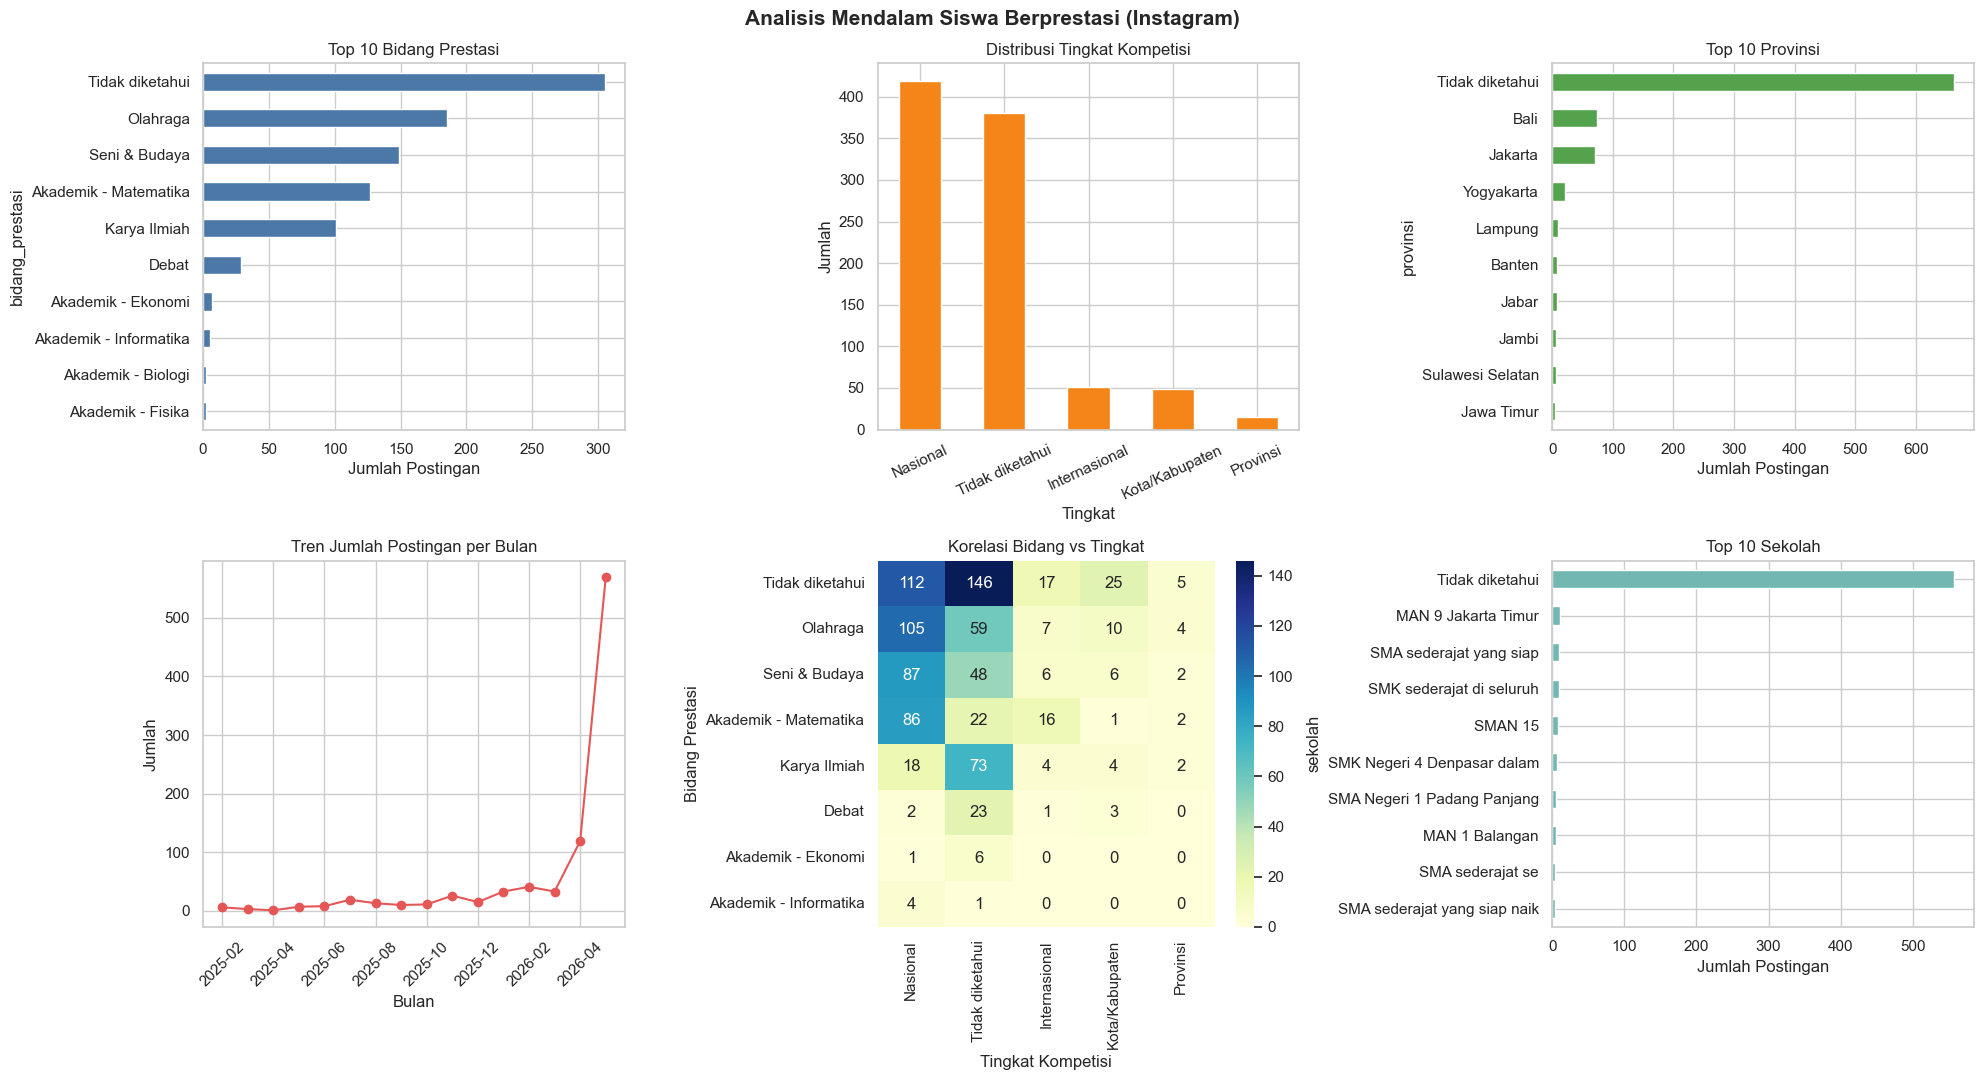

✅ Visualisasi mendalam disimpan: visualisasi_siswa_berprestasi_mendalam.png


In [7]:
df_viz = df_prestasi.copy()
df_viz["tanggal_post"] = pd.to_datetime(df_viz["tanggal_post"], errors="coerce")

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Analisis Mendalam Siswa Berprestasi (Instagram)", fontsize=15, fontweight="bold")

# 1) Top bidang prestasi
bidang_counts = df_viz["bidang_prestasi"].fillna("Tidak diketahui").value_counts().head(10)
if not bidang_counts.empty:
    bidang_counts.sort_values().plot(kind="barh", ax=axes[0, 0], color="#4C78A8")
    axes[0, 0].set_title("Top 10 Bidang Prestasi")
    axes[0, 0].set_xlabel("Jumlah Postingan")
else:
    axes[0, 0].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

# 2) Top tingkat kompetisi
tingkat_counts = df_viz["tingkat_kompetisi"].fillna("Tidak diketahui").value_counts()
if not tingkat_counts.empty:
    tingkat_counts.plot(kind="bar", ax=axes[0, 1], color="#F58518")
    axes[0, 1].set_title("Distribusi Tingkat Kompetisi")
    axes[0, 1].set_xlabel("Tingkat")
    axes[0, 1].set_ylabel("Jumlah")
    axes[0, 1].tick_params(axis="x", rotation=25)
else:
    axes[0, 1].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

# 3) Top provinsi
prov_counts = df_viz["provinsi"].fillna("Tidak diketahui").value_counts().head(10)
if not prov_counts.empty:
    prov_counts.sort_values().plot(kind="barh", ax=axes[0, 2], color="#54A24B")
    axes[0, 2].set_title("Top 10 Provinsi")
    axes[0, 2].set_xlabel("Jumlah Postingan")
else:
    axes[0, 2].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

# 4) Tren posting per bulan
trend = (
    df_viz.dropna(subset=["tanggal_post"])
    .assign(bulan=lambda x: x["tanggal_post"].dt.to_period("M").astype(str))
    .groupby("bulan")
    .size()
    .sort_index()
)
if not trend.empty:
    trend.plot(ax=axes[1, 0], marker="o", color="#E45756")
    axes[1, 0].set_title("Tren Jumlah Postingan per Bulan")
    axes[1, 0].set_xlabel("Bulan")
    axes[1, 0].set_ylabel("Jumlah")
    axes[1, 0].tick_params(axis="x", rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, "Tidak ada data tanggal", ha="center", va="center")

# 5) Heatmap bidang x tingkat
ct = pd.crosstab(
    df_viz["bidang_prestasi"].fillna("Tidak diketahui"),
    df_viz["tingkat_kompetisi"].fillna("Tidak diketahui")
)
if not ct.empty:
    top_rows = ct.sum(axis=1).sort_values(ascending=False).head(8).index
    top_cols = ct.sum(axis=0).sort_values(ascending=False).head(5).index
    sns.heatmap(ct.loc[top_rows, top_cols], annot=True, fmt="d", cmap="YlGnBu", ax=axes[1, 1])
    axes[1, 1].set_title("Korelasi Bidang vs Tingkat")
    axes[1, 1].set_xlabel("Tingkat Kompetisi")
    axes[1, 1].set_ylabel("Bidang Prestasi")
else:
    axes[1, 1].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

# 6) Top sekolah
sekolah_counts = df_viz["sekolah"].fillna("Tidak diketahui").value_counts().head(10)
if not sekolah_counts.empty:
    sekolah_counts.sort_values().plot(kind="barh", ax=axes[1, 2], color="#72B7B2")
    axes[1, 2].set_title("Top 10 Sekolah")
    axes[1, 2].set_xlabel("Jumlah Postingan")
else:
    axes[1, 2].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

plt.tight_layout()
plt.savefig("visualisasi_siswa_berprestasi_mendalam.png", dpi=160, bbox_inches="tight")
plt.show()
print("✅ Visualisasi mendalam disimpan: visualisasi_siswa_berprestasi_mendalam.png")

## 8. Simpan Data

In [8]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

df.to_csv(f"data_instagram_all_{timestamp}.csv", index=False, encoding="utf-8-sig")
print(f"✅ CSV semua data          : data_instagram_all_{timestamp}.csv")

df_prestasi.to_csv(f"data_siswa_berprestasi_{timestamp}.csv", index=False, encoding="utf-8-sig")
print(f"✅ CSV prestasi            : data_siswa_berprestasi_{timestamp}.csv")

with pd.ExcelWriter(f"data_siswa_berprestasi_{timestamp}.xlsx", engine="openpyxl") as writer:
    df_prestasi.to_excel(writer, sheet_name="Siswa Berprestasi", index=False)
    df_prestasi[df_prestasi["is_kelas_xi"]].to_excel(writer, sheet_name="Kelas XI 2026", index=False)
    df.to_excel(writer, sheet_name="Semua Data", index=False)
print(f"✅ Excel (3 sheet)         : data_siswa_berprestasi_{timestamp}.xlsx")

with open(f"raw_posts_{timestamp}.json", "w", encoding="utf-8") as f:
    json.dump(all_posts, f, ensure_ascii=False, indent=2, default=str)
print(f"✅ JSON backup             : raw_posts_{timestamp}.json")


✅ CSV semua data          : data_instagram_all_20260508_120725.csv
✅ CSV prestasi            : data_siswa_berprestasi_20260508_120725.csv
✅ Excel (3 sheet)         : data_siswa_berprestasi_20260508_120725.xlsx
✅ JSON backup             : raw_posts_20260508_120725.json


## 9. Ringkasan Akhir

In [9]:
print("=" * 55)
print("   RINGKASAN DATA SISWA BERPRESTASI SMA/SMP 2026")
print("=" * 55)
print(f"Total data di-scrape          : {len(df)}")
print(f"  - Instagram                 : {(df['sumber'] == 'instagram').sum()}")
print("  - Berita online             : 0 (dinonaktifkan)")
print(f"Postingan relevan prestasi    : {len(df_prestasi)}")
print(f"Terdeteksi kelas XI           : {df_prestasi['is_kelas_xi'].fillna(False).astype(bool).sum()}")
print(f"Nama siswa terdeteksi         : {df_prestasi['nama_siswa'].notna().sum()}")
print(f"Sekolah terdeteksi            : {df_prestasi['sekolah'].notna().sum()}")
print(f"Provinsi terdeteksi           : {df_prestasi['provinsi'].notna().sum()}")
print()

cols = ["url", "tanggal_post", "nama_siswa", "sekolah", "provinsi",
        "bidang_prestasi", "tingkat_kompetisi", "info_juara", "is_kelas_xi", "sumber"]

df_tabel = df_prestasi.copy()
for c in cols:
    if c not in df_tabel.columns:
        df_tabel[c] = pd.NA

df_tabel["tanggal_post"] = pd.to_datetime(df_tabel["tanggal_post"], errors="coerce")
df_tabel = df_tabel.sort_values("tanggal_post", ascending=False)
df_tabel["tanggal_post"] = df_tabel["tanggal_post"].dt.strftime("%Y-%m-%d %H:%M:%S")
df_tabel["tanggal_post"] = df_tabel["tanggal_post"].fillna("-")

for c in ["nama_siswa", "sekolah", "provinsi", "bidang_prestasi", "tingkat_kompetisi", "info_juara", "sumber"]:
    df_tabel[c] = df_tabel[c].fillna("-")

df_tabel["is_kelas_xi"] = df_tabel["is_kelas_xi"].fillna(False).astype(bool).map({True: "Ya", False: "Tidak"})
df_tabel = df_tabel[cols]

print("Preview tabel rapi (20 baris terbaru):")
df_tabel.head(20)


   RINGKASAN DATA SISWA BERPRESTASI SMA/SMP 2026
Total data di-scrape          : 1025
  - Instagram                 : 1025
  - Berita online             : 0 (dinonaktifkan)
Postingan relevan prestasi    : 914
Terdeteksi kelas XI           : 98
Nama siswa terdeteksi         : 105
Sekolah terdeteksi            : 357
Provinsi terdeteksi           : 251

Preview tabel rapi (20 baris terbaru):


,url,tanggal_post,nama_siswa,sekolah,provinsi,bidang_prestasi,tingkat_kompetisi,info_juara,is_kelas_xi,sumber
649,https://www.instagram.com/p/DYEKbnkPJz2/,2026-05-08 04:56:18,masih sangat besar untuk,-,-,Akademik - Matematika,Nasional,Juara 2 Lomba OSN Matematika Tingkat Kecamatan...,Ya,instagram
7,https://www.instagram.com/p/DYEKaU5zxSW/,2026-05-08 04:56:08,Kayla Khansa Izdihar,SMAN 39,Jakarta,Seni & Budaya,Nasional,Juara 3 dalam ajang National Folklore Festival...,Tidak,instagram
678,https://www.instagram.com/p/DYEKXoWPCg1/,2026-05-08 04:55:46,dalam menuntut ilmu,-,-,Karya Ilmiah,Nasional,Juara 3 Lomba OSN IPA Tingkat Kecamatan Tahun ...,Ya,instagram
650,https://www.instagram.com/p/DYEKTc0PkDY/,2026-05-08 04:55:12,dan bimbingan bapak,-,-,-,Nasional,Juara 2 Lomba OSN IPA Tingkat Kecamatan Tahun ...,Ya,instagram
235,https://www.instagram.com/p/DYEKPRvkgn_/,2026-05-08 04:54:37,-,SMP NEGERI 2 SUKOREJO,-,-,Nasional,-,Tidak,instagram
236,https://www.instagram.com/p/DYEKNw1EhU1/,2026-05-08 04:54:23,-,SMK yang siap bersaing,-,-,Nasional,juara,Tidak,instagram
584,https://www.instagram.com/p/DYEKB-4PF7b/,2026-05-08 04:52:49,pada ilmu pengetahuan,-,-,Karya Ilmiah,Nasional,Juara 1 Lomba OSN IPS Tingkat Kecamatan Tahun ...,Ya,instagram
585,https://www.instagram.com/p/DYEJvLjE0m4/,2026-05-08 04:50:12,Maila Hana Sekar Mazaya,SMAN 39,Jakarta,-,Nasional,Juara 1 dalam ajang Lomba Fashion Show Berkeba...,Ya,instagram
586,https://www.instagram.com/p/DYEJq7QgXwA/,2026-05-08 04:49:37,Muhammad Ghanim Dzaky,-,-,Olahraga,Nasional,Juara 3,Tidak,instagram
525,https://www.instagram.com/p/DYEJmfPExt3/,2026-05-08 04:49:01,-,SMP Islam Al Azhar,Jakarta,Olahraga,Nasional,Juara 1 Lomba Ilustrasi,Tidak,instagram
